## Loading data

YouNiverse data downloadable at: https://zenodo.org/records/4650046

In [12]:
import pandas as pd
import numpy as np
import gzip
import json
import csv
from plotnine import *

In [3]:
# 1. Load channels
print("Loading channels...")
df_channels = pd.read_csv('../0_data/df_channels_en.tsv.gz', sep='\t', compression='gzip')
df_channels.head()

Loading channels...


,category_cc,join_date,channel,name_cc,subscribers_cc,videos_cc,subscriber_rank_sb,weights
0,Gaming,2010-04-29,UC-lHJZR3Gqxm24_Vd_AJ5Yw,PewDiePie,101000000,3956,3.0,2.087
1,Education,2006-09-01,UCbCmjCuTUZos6Inko4u57UQ,Cocomelon - Nursery ...,60100000,458,7.0,2.087
2,Entertainment,2006-09-20,UCpEhnqL0y41EpW2TvWAHD7Q,SET India,56018869,32661,8.0,2.087
3,Howto & Style,2016-11-15,UC295-Dw_tDNtZXFeAPAW6Aw,5-Minute Crafts,60600000,3591,9.0,2.087
4,Sports,2007-05-11,UCJ5v_MCY6GNUBTO8-D3XoAg,WWE,48400000,43421,11.0,2.087


In [4]:
# Filter for ACTIVE channels first
mask_viable = (df_channels['videos_cc'] >= 20) & (df_channels['subscribers_cc'] >= 1000)
df_viable = df_channels[mask_viable]

print(f"Found {len(df_viable)} viable channels out of {len(df_channels)} total.")

Found 130202 viable channels out of 136470 total.


In [5]:
# Now randomly sample 10,000 from the viable ones
# random_state=42 for reproducibility
sample_channels = df_viable.sample(n=10000, random_state=42)

# Create a set of target IDs
target_channel_ids = set(sample_channels['channel'].tolist())

print(f"Targeting {len(target_channel_ids)} random active channels.")

Targeting 10000 random active channels.


In [40]:
# 2. Process videos
input_file = '../0_data/yt_metadata_en.jsonl.gz'
output_file = '../0_data/random_sampled_10000.csv'

print("Scanning video database...")

with gzip.open(input_file, 'rt', encoding='utf-8') as f_in, \
     open(output_file, 'w', newline='', encoding='utf-8') as f_out:
    
    writer = csv.writer(f_out)
    header = ['video_id', 'channel_id', 'upload_date', 'title', 'tags', 'category', 'view_count', 'like_count']
    writer.writerow(header)
    
    saved_count = 0
    
    for line in f_in:
        try:
            video = json.loads(line)
            if video['channel_id'] in target_channel_ids:
                raw_cat = video.get('categories', "Unknown")
                
                if isinstance(raw_cat, list):
                    # Case A: It's a list like ["Gaming"] -> Take the first item
                    category_str = raw_cat[0] if len(raw_cat) > 0 else "Unknown"
                else:
                    # Case B: It's already a string like "Gaming" -> Use it directly
                    category_str = str(raw_cat)
                
                writer.writerow([
                    video['display_id'],
                    video['channel_id'],
                    video['upload_date'],
                    video['title'],
                    video['tags'],
                    category_str,
                    video['view_count'],
                    video['like_count']
                ])
                saved_count += 1
        except (ValueError, KeyError):
            continue

print(f"Done! Saved {saved_count} videos from 10,000 random channels.")

Scanning video database...
Done! Saved 5462722 videos from 10,000 random channels.


In [42]:
df_videos = pd.read_csv('../0_data/random_sampled_10000.csv')
df_videos.head()

,video_id,channel_id,upload_date,title,tags,category,view_count,like_count
0,SBqSc91Hn9g,UCzWrhkg9eK5I8Bm3HfV-unA,2016-09-28 00:00:00,Lego City Police Lego Firetruck Cartoons about...,"lego city,lego police,lego city police,lego ci...",Film & Animation,1057.0,8.0
1,UuugEl86ESY,UCzWrhkg9eK5I8Bm3HfV-unA,2016-09-28 00:00:00,Lego Marvel SuperHeroes Lego Hulk Smash Iron-M...,"Lego superheroes,lego hulk,hulk smash,lego mar...",Film & Animation,12894.0,23.0
2,oB4c-yvnbjs,UCzWrhkg9eK5I8Bm3HfV-unA,2016-09-28 00:00:00,Lego City Police Lego Fireman Cartoons about L...,"lego city,lego police,lego city police,lego fi...",Film & Animation,1800602.0,1607.0
3,ZaV-gTCMV8E,UCzWrhkg9eK5I8Bm3HfV-unA,2016-09-28 00:00:00,Lego Harry Potter Complete Lego New Movie for ...,"Lego harry potter,new harry potter,harry potte...",Film & Animation,57640.0,227.0
4,cGvL7AvMfM0,UCzWrhkg9eK5I8Bm3HfV-unA,2016-09-28 00:00:00,Lego City Police 1 HOUR LONG VIDEO for kids Le...,"lego city,lego police,lego city police,lego fi...",Film & Animation,86368.0,105.0


In [43]:
df_videos.shape

(5462722, 8)

## Descriptive analysis

### 1. View counts

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_bin : Removed 18 rows containing non-finite values.


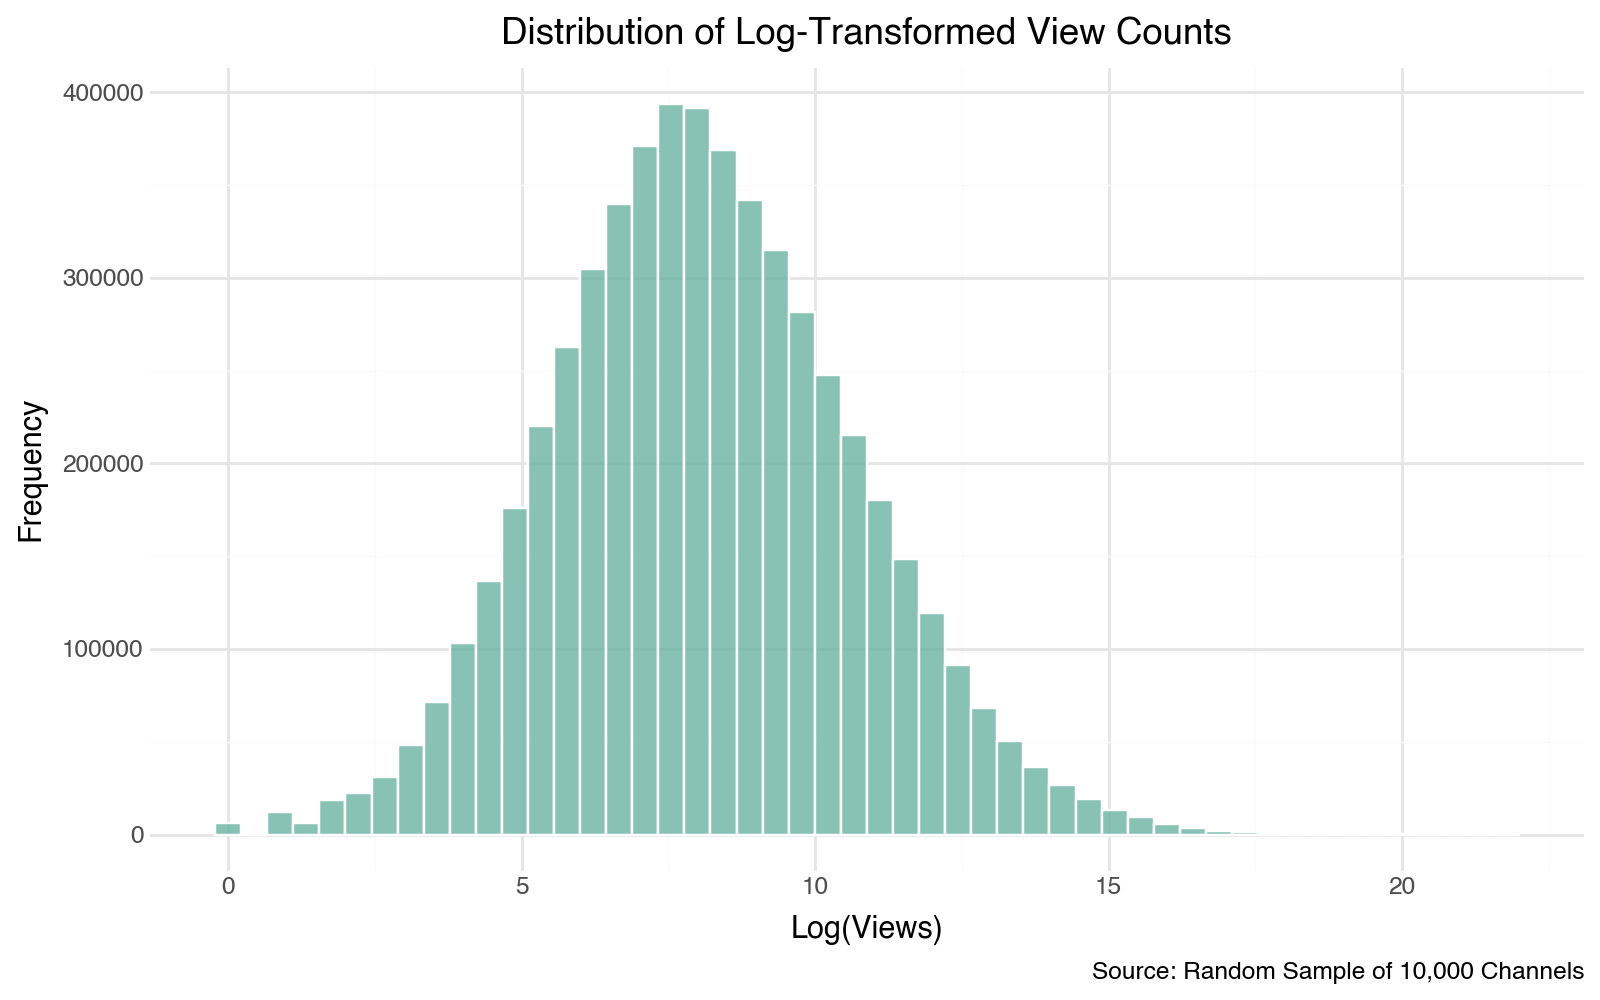

In [44]:
# Create a Log-Transformed column for plotting (log of views + 1 to avoid log(0))
df_videos['log_views'] = np.log1p(df_videos['view_count'])

# Calculate Videos per Channel
channel_counts = df_videos.groupby('channel_id').size().reset_index(name='video_count')

# PLOT 1: The "Power Law" Check (Log-Transformed Views)
# Strategy Requirement: We need to show that views follow a log-normal distribution.
# If this plot looks like a Bell Curve, the regression will work well.

plot_views = (
    ggplot(df_videos, aes(x='log_views'))
    + geom_histogram(bins=50, fill="#69b3a2", color="white", alpha=0.8)
    + labs(
        title="Distribution of Log-Transformed View Counts",
        x="Log(Views)",
        y="Frequency",
        caption="Source: Random Sample of 10,000 Channels"
    )
    + theme_minimal()
    + theme(figure_size=(8, 5))
)
plot_views

Original size: 5462722
Cleaned size:  5456264
Dropped 6458 useless rows.


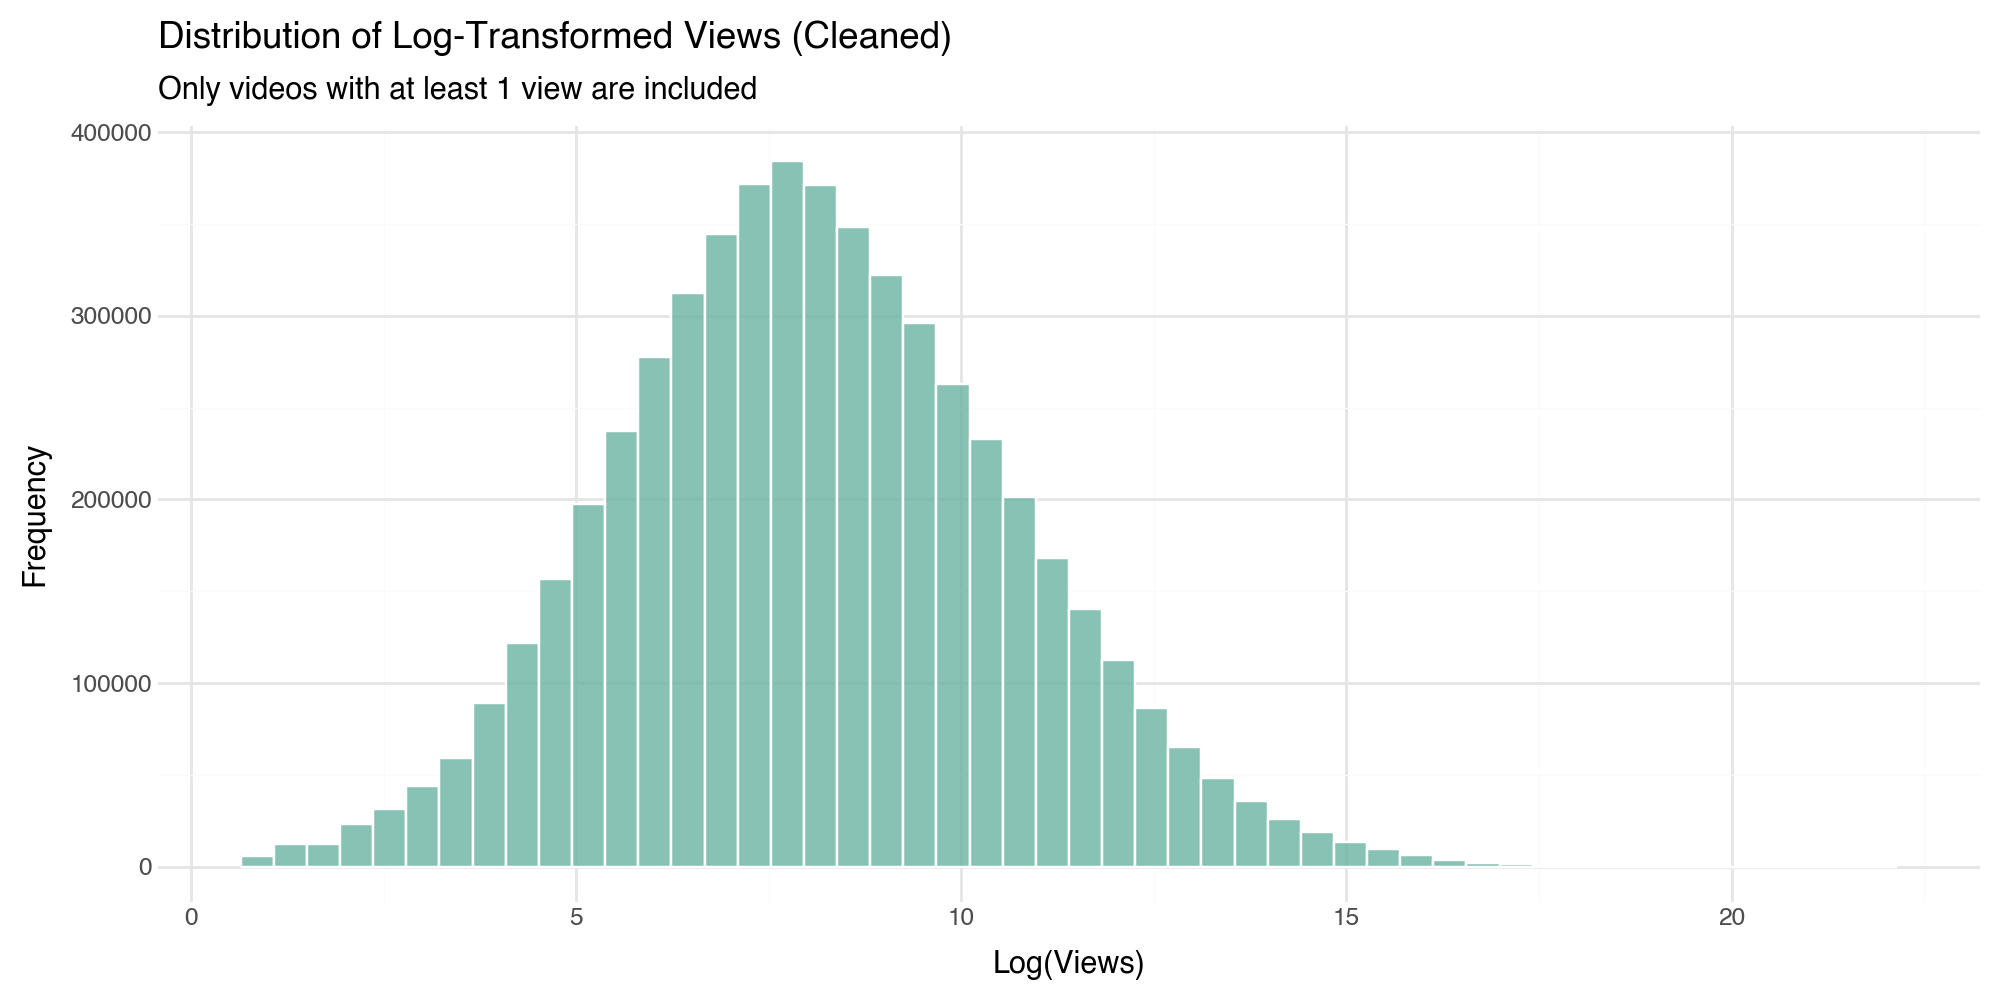

In [53]:
# Remove rows where view_count is NaN (fix the warning)
df_clean = df_videos.dropna(subset=['view_count'])

# Filter videos that have > 0 views
df_clean = df_clean[df_clean['view_count'] > 0]

print(f"Original size: {len(df_videos)}")
print(f"Cleaned size:  {len(df_clean)}")
print(f"Dropped {len(df_videos) - len(df_clean)} useless rows.")

# Re-Calculate logs
df_clean['log_views'] = np.log1p(df_clean['view_count'])

# Re-plot
plot_clean = (
    ggplot(df_clean, aes(x='log_views'))
    + geom_histogram(bins=50, fill="#69b3a2", color="white", alpha=0.8)
    + labs(
        title="Distribution of Log-Transformed Views (Cleaned)",
        subtitle="Only videos with at least 1 view are included",
        x="Log(Views)",
        y="Frequency"
    )
    + theme_minimal()
    + theme(figure_size=(10, 5))
)
plot_clean

### 2. Like counts

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_bin : Removed 113473 rows containing non-finite values.


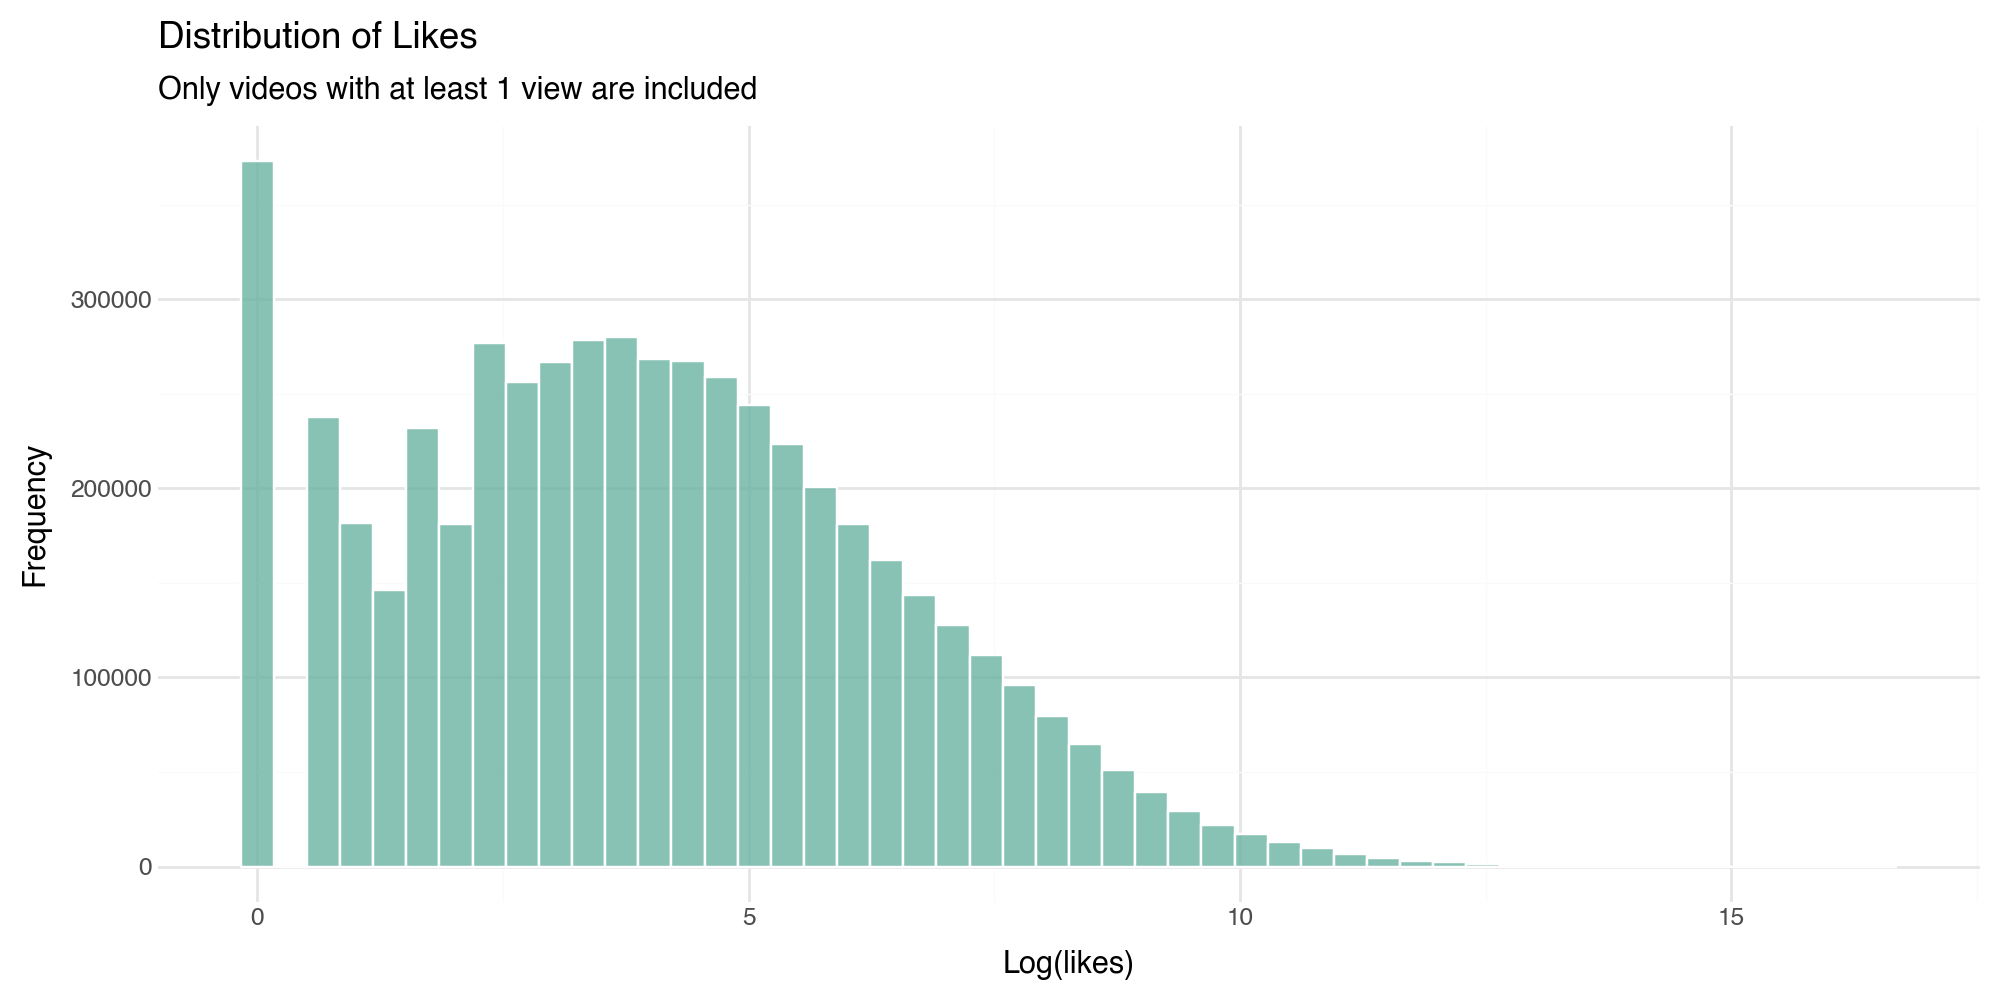

In [49]:
# Log-transformed likes
df_clean['log_likes'] = np.log1p(df_clean['like_count'])

plot_likes = (
    ggplot(df_clean, aes(x='log_likes'))
    + geom_histogram(bins=50, fill="#69b3a2", color="white", alpha=0.8)
    + labs(
        title="Distribution of Likes",
        subtitle="Only videos with at least 1 view are included",
        x="Log(likes)",
        y="Frequency"
    )
    + theme_minimal()
    + theme(figure_size=(10, 5))
)
plot_likes

### 3. Videos per channel

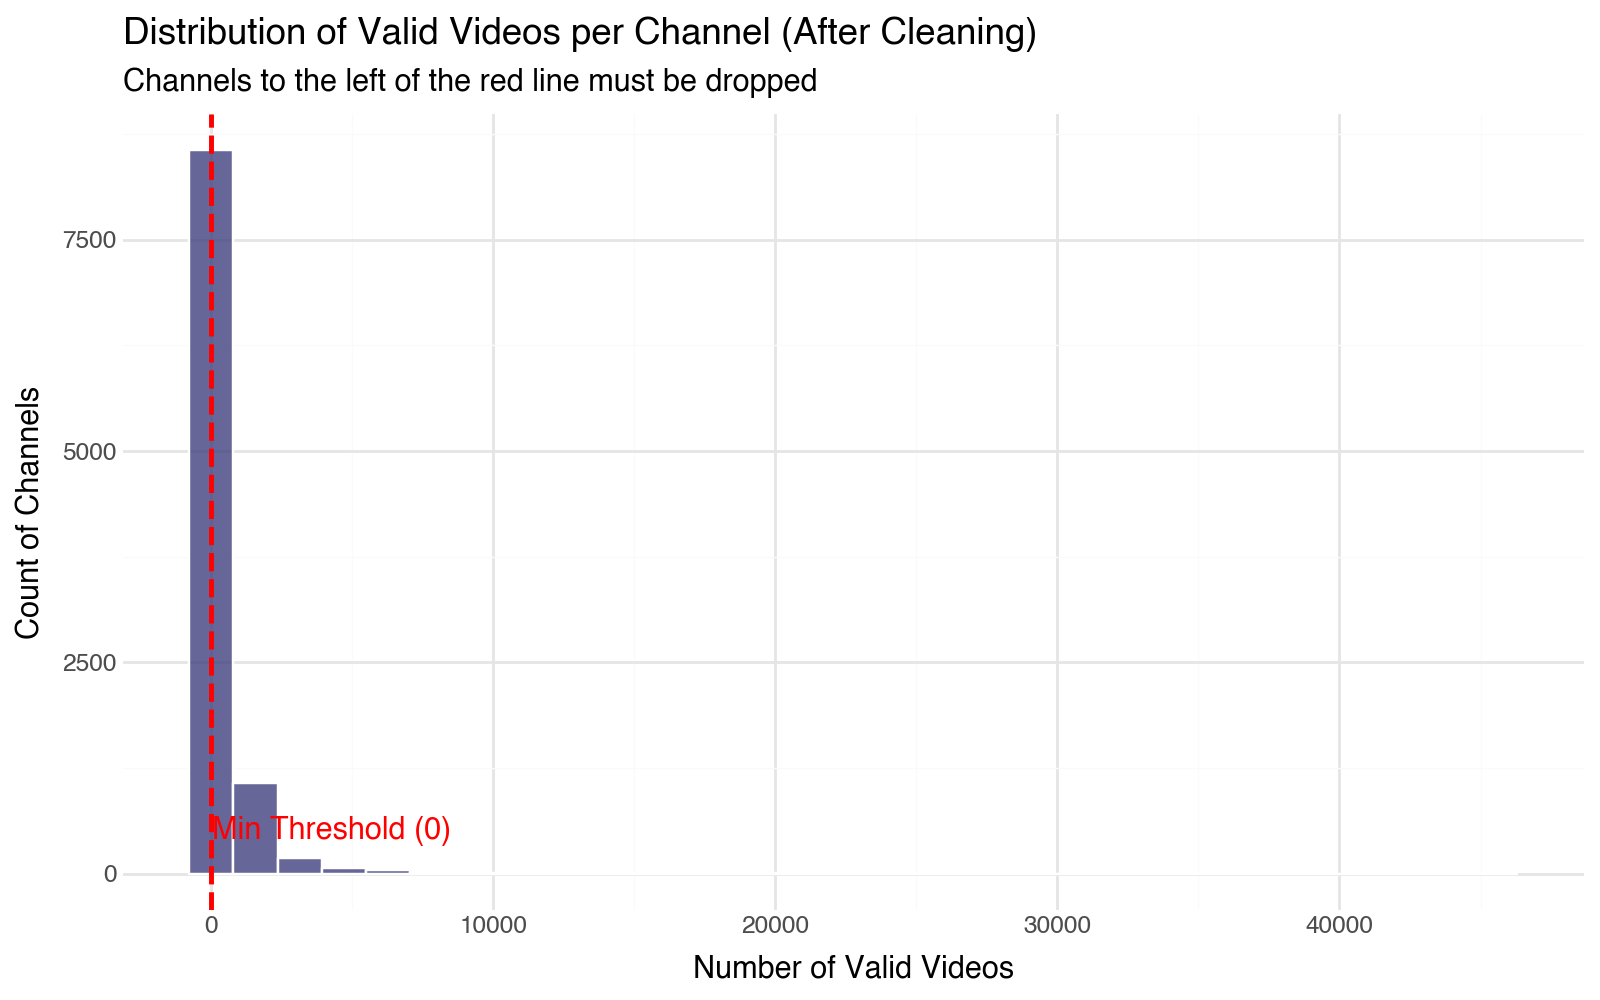

In [56]:
# Re-calculate COUNTS on the clean data
# We need to know how many valid videos each channel has left
clean_channel_counts = df_clean.groupby('channel_id').size().reset_index(name='video_count')

# 2. Plot the new distribution
plot_counts_clean = (
    ggplot(clean_channel_counts, aes(x='video_count'))
    + geom_histogram(bins=30, fill="#404080", color="white", alpha=0.8)
    + geom_vline(xintercept=10, linetype="dashed", color="red", size=1)
    + annotate("text", x=12, y=500, label="Min Threshold (0)", color="red", ha="left")
    + labs(
        title="Distribution of Valid Videos per Channel (After Cleaning)",
        subtitle="Channels to the left of the red line must be dropped",
        x="Number of Valid Videos",
        y="Count of Channels"
    )
    + theme_minimal()
    + theme(figure_size=(8, 5))
)
plot_counts_clean

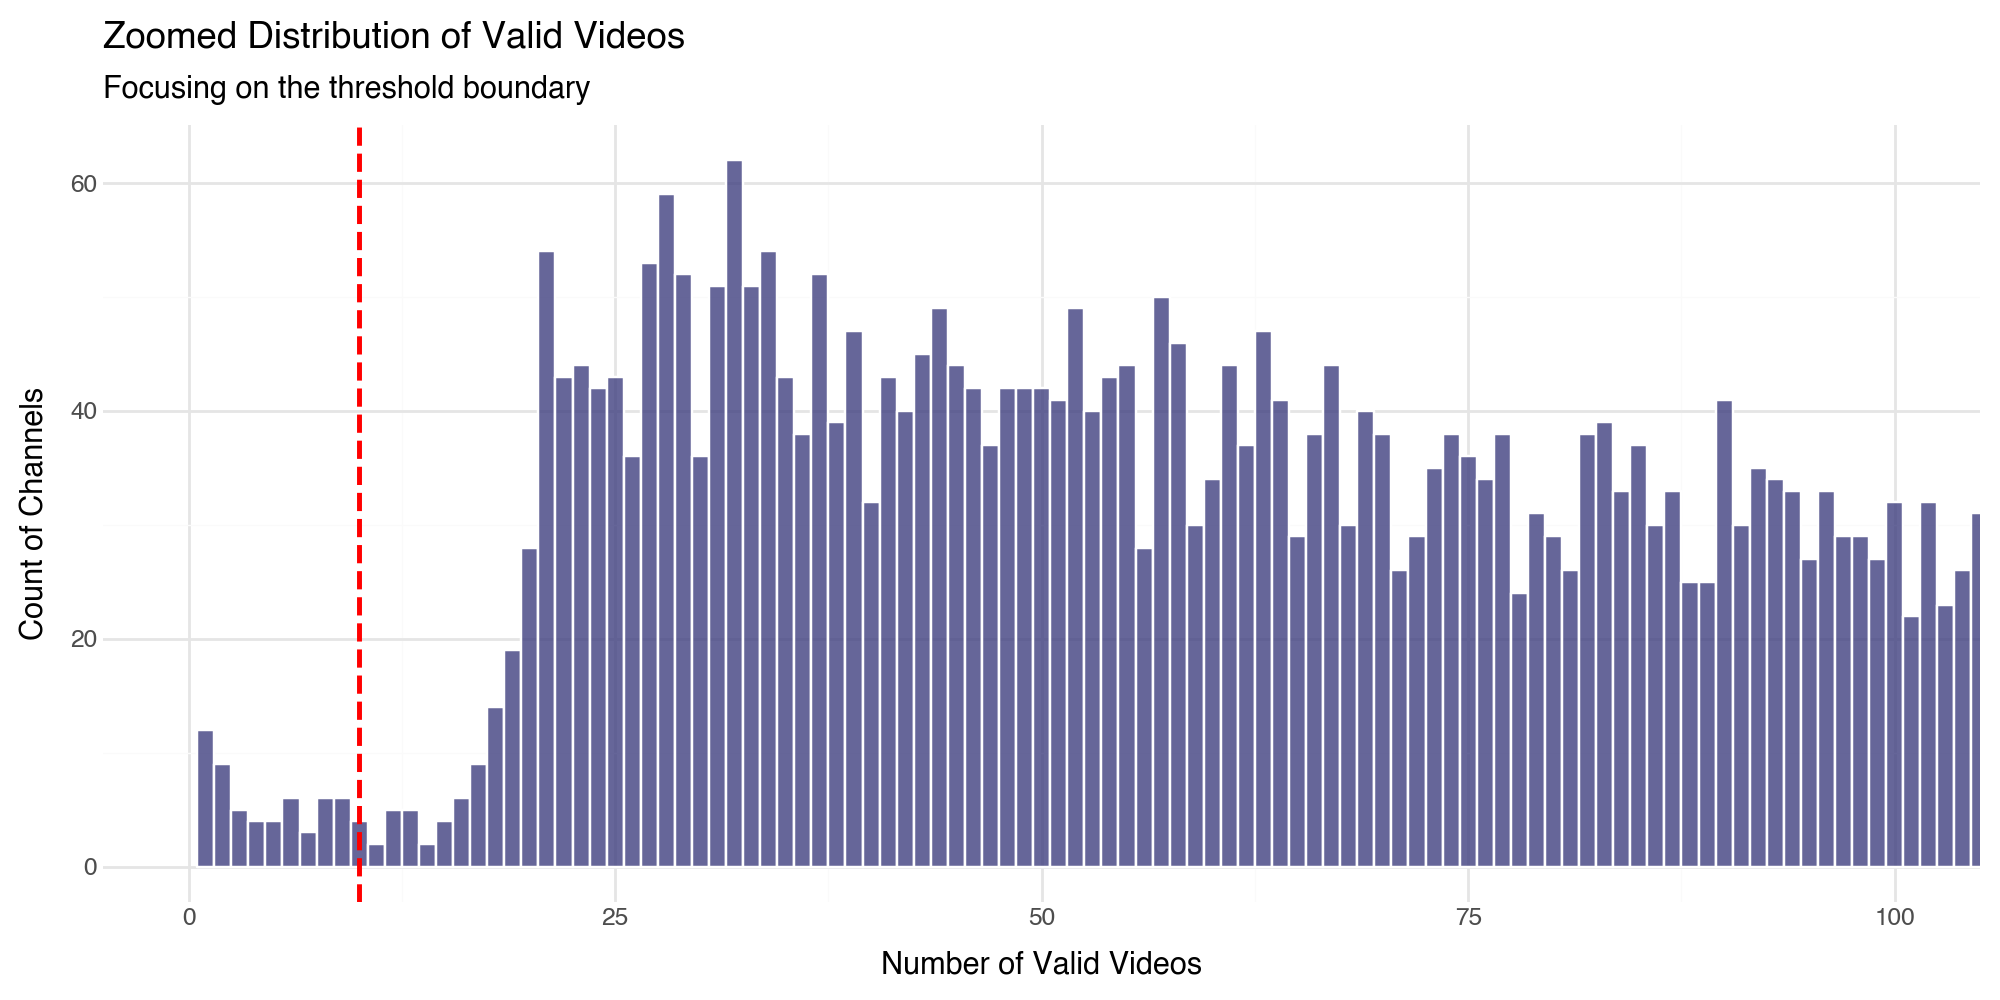

In [57]:
# Re-plot to exclude outliers
plot_counts_zoomed = (
    ggplot(clean_channel_counts, aes(x='video_count'))
    + geom_histogram(binwidth=1, fill="#404080", color="white", alpha=0.8) # Binwidth=1 shows exact counts
    + geom_vline(xintercept=10, linetype="dashed", color="red", size=1)
    + coord_cartesian(xlim=(0, 100)) # ZOOM IN: Ignore the 30k outlier for a second
    + labs(
        title="Zoomed Distribution of Valid Videos",
        subtitle="Focusing on the threshold boundary",
        x="Number of Valid Videos",
        y="Count of Channels"
    )
    + theme_minimal()
    + theme(figure_size=(10, 5))
)
plot_counts_zoomed

In [58]:
# Identify channels that have enough history (>= 10 videos)
valid_channels = clean_channel_counts[clean_channel_counts['video_count'] >= 10]['channel_id']

# Create an intermediate dataframe with only valid channels
df_final = df_clean[df_clean['channel_id'].isin(valid_channels)].copy()

print("\n--- STATUS AFTER MIN FILTER (>=10) ---")
print(f"Channels remaining: {len(valid_channels)}")
print(f"Videos remaining:   {len(df_final)}")


--- STATUS AFTER MIN FILTER (>=10) ---
Channels remaining: 9945
Videos remaining:   5456024


In [59]:
# Calculate the 99th percentile (Where do 99% of normal channels fall?)
# We calculate this based on the *valid* channels we just found.
upper_limit = clean_channel_counts[clean_channel_counts['channel_id'].isin(valid_channels)]['video_count'].quantile(0.99)

print(f"\n99% of valid channels have fewer than {upper_limit:.0f} videos.")
print(f"Removing channels above this limit (Super-Uploaders)...")


99% of valid channels have fewer than 6190 videos.
Removing channels above this limit (Super-Uploaders)...


In [60]:
# Identify the specific channels that are "Normal" (Valid AND not Super-Uploaders)
# Logic: Must be in 'valid_channels' AND have fewer videos than 'upper_limit'
normal_channel_mask = (clean_channel_counts['channel_id'].isin(valid_channels)) & \
                      (clean_channel_counts['video_count'] < upper_limit)

normal_channels = clean_channel_counts[normal_channel_mask]['channel_id']

# Create the FINAL research-ready dataframe
df_research_ready = df_clean[df_clean['channel_id'].isin(normal_channels)].copy()

print("\n--- FINAL RESEARCH DATASET STATUS ---")
print(f"Original Videos (Cleaned): {len(df_clean)}")
print(f"Final Videos (Filtered):   {len(df_research_ready)}")
print(f"Dropped {len(df_clean) - len(df_research_ready)} videos in total (Low history + Super-uploaders).")

print("\nDescriptive Stats for Final Data:")
print(df_research_ready['view_count'].describe().apply(lambda x: format(x, 'f')))


--- FINAL RESEARCH DATASET STATUS ---
Original Videos (Cleaned): 5456264
Final Videos (Filtered):   4143369
Dropped 1312895 videos in total (Low history + Super-uploaders).

Descriptive Stats for Final Data:
count       4143369.000000
mean         161147.903736
std         4259253.084251
min               1.000000
25%             918.000000
50%            4449.000000
75%           24846.000000
max      2843572528.000000
Name: view_count, dtype: object


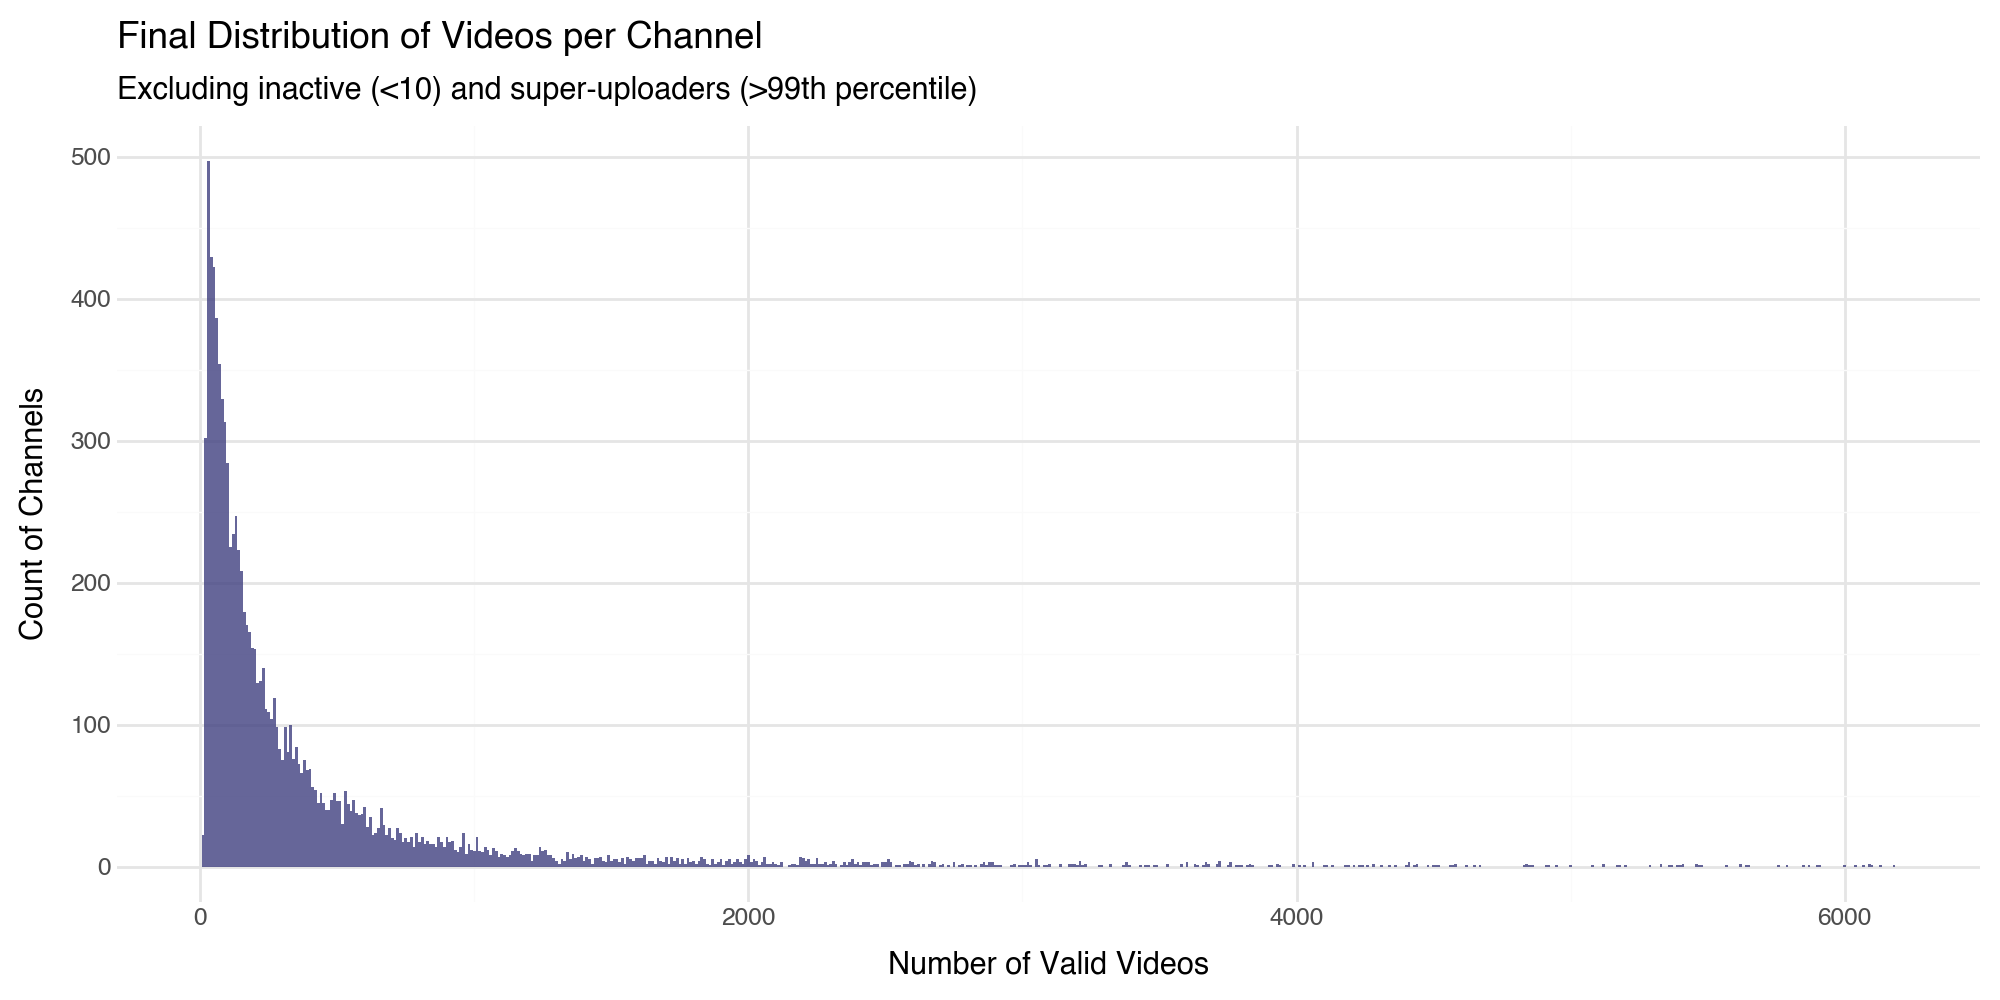

In [63]:
# Calculate the final counts for the research-ready dataset
final_channel_counts = df_research_ready.groupby('channel_id').size().reset_index(name='video_count')

# Plot the Distribution
plot_final_dist = (
    ggplot(final_channel_counts, aes(x='video_count'))
    + geom_histogram(binwidth=10, fill="#404080", alpha=0.8) 
    + labs(
        title="Final Distribution of Videos per Channel",
        subtitle="Excluding inactive (<10) and super-uploaders (>99th percentile)",
        x="Number of Valid Videos",
        y="Count of Channels"
    )
    + theme_minimal()
    + theme(figure_size=(10, 5))
)

plot_final_dist

In [64]:
# Print the exact range to confirm the outliers are gone
print(f"Range of video counts: {final_channel_counts['video_count'].min()} to {final_channel_counts['video_count'].max()}")

Range of video counts: 10 to 6185
